In [92]:
import tensorflow as tf
import scipy.io as sio
import h5py

In [93]:
tf.__version__

'2.21.0'

In [94]:
# To generate GIFs
!pip install imageio
!pip install git+https://github.com/tensorflow/docs


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/tensorflow/docs to c:\users\marla barto\appdata\local\temp\pip-req-build-oxis_t4v
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs 'C:\Users\Marla Barto\AppData\Local\Temp\pip-req-build-oxis_t4v'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

In [96]:
train_data = sio.loadmat('train_32x32.mat')
test_data = sio.loadmat('test_32x32.mat')

In [97]:
train_images = train_data['X']
train_labels = train_data['y']

train_images = np.transpose(train_images, (3, 0, 1, 2)).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1] for tanh output

# Balanced speed/quality: 35k subset.
subset_size = 35000
if subset_size is not None:
    train_images = train_images[:subset_size]

In [98]:
BUFFER_SIZE = train_images.shape[0]
BATCH_SIZE = 128

In [99]:
# Batch, shuffle, and prefetch the data
train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

In [100]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(100,)))
    model.add(layers.Dense(4 * 4 * 512, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((4, 4, 512)))
    assert model.output_shape == (None, 4, 4, 512)

    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 256)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2D(3, (5, 5), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

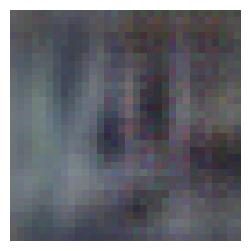

In [101]:
# Avoid resetting trained weights when previewing.
if 'generator' not in globals():
    generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

preview = tf.clip_by_value((generated_image[0] + 1) / 2, 0.0, 1.0)
plt.figure(figsize=(3, 3))
plt.imshow(preview, interpolation='nearest')
plt.axis('off')
plt.show()

In [102]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=[32, 32, 3]))
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [103]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

tf.Tensor([[-0.03085695]], shape=(1, 1), dtype=float32)


In [104]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [105]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [106]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [107]:
# Stable LR setting
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

In [108]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [109]:
EPOCHS = 20
noise_dim = 100
num_examples_to_generate = 16

# Save one frame each epoch so the GIF includes all epochs.
preview_every = 1

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [110]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [111]:
def train(dataset, epochs):
  # Start from a clean frame set so the GIF is built from one run only.
  for filename in glob.glob('image_at_epoch_*.png'):
    os.remove(filename)

  if os.path.exists('dcgan.gif'):
    os.remove('dcgan.gif')

  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      gen_loss, disc_loss = train_step(image_batch)

    # Produce preview frames every epoch
    if (epoch + 1) % preview_every == 0 or (epoch + 1) == epochs:
      display.clear_output(wait=True)
      generate_and_save_images(generator,
                               epoch + 1,
                               seed)

    # Save checkpoints periodically and at the very end
    if (epoch + 1) % 15 == 0 or (epoch + 1) == epochs:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print('Time for epoch {} is {} sec | Gen Loss: {:.4f} | Disc Loss: {:.4f}'.format(
    epoch + 1, time.time()-start, gen_loss, disc_loss))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

In [112]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))
  fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i + 1)
      image = tf.clip_by_value((predictions[i] + 1) / 2, 0.0, 1.0)
      plt.imshow(image, interpolation='nearest')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch), dpi=120, bbox_inches=None, pad_inches=0)
  plt.show()

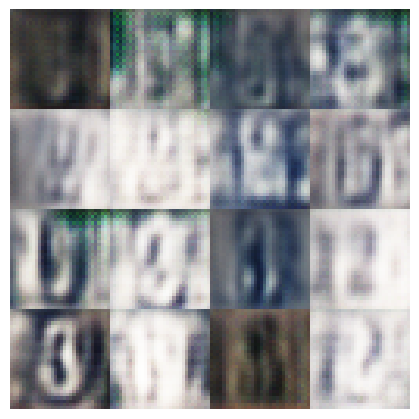

In [113]:
train(train_dataset, EPOCHS)

In [114]:
# Restore from the strongest checkpoint candidate found in comparison.
checkpoint.restore(os.path.join(checkpoint_dir, 'ckpt-2'))

In [115]:
# Display a single image using the epoch number
def display_image(epoch_no, max_size=(640, 640)):
  target = 'image_at_epoch_{:04d}.png'.format(epoch_no)
  if not os.path.exists(target):
    frames = sorted(glob.glob('image_at_epoch_*.png'))
    if not frames:
      raise FileNotFoundError('No saved epoch images found. Run training first.')
    target = frames[-1]

  img = PIL.Image.open(target)
  img.thumbnail(max_size, PIL.Image.Resampling.NEAREST)
  return img

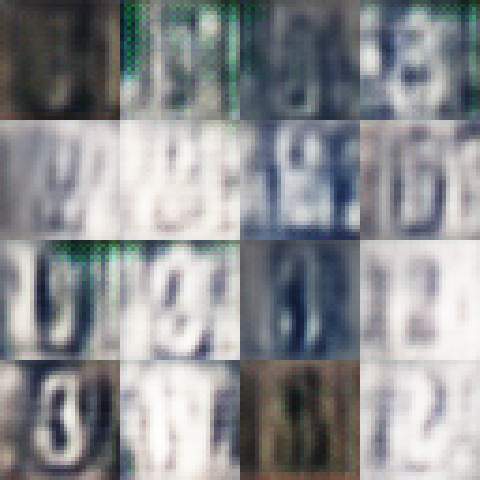

In [116]:
display_image(EPOCHS)

In [117]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = sorted(glob.glob('image_at_epoch_*.png'))
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  if filenames:
    writer.append_data(imageio.imread(filenames[-1]))

C:\Users\Marla Barto\AppData\Local\Temp\ipykernel_26492\2988504102.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
C:\Users\Marla Barto\AppData\Local\Temp\ipykernel_26492\2988504102.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filenames[-1]))



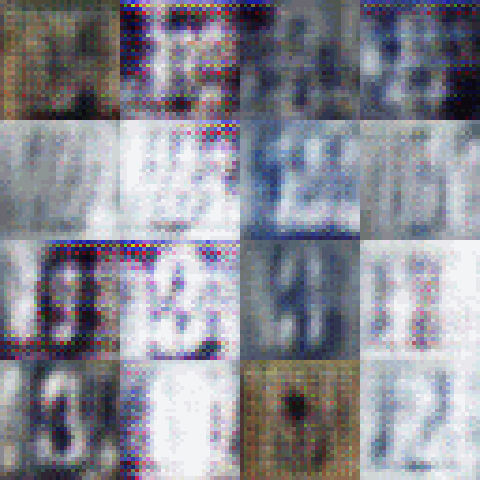

In [118]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)